# Linear Regression Complete Workflow

---

# 1. Understand the Problem

First decide:

- What do you want to predict?

Examples:

- House Price
- Salary
- Student Marks

The predicted value is called:

## Target Variable (y)

---

# 2. Collect Dataset

Gather data related to the problem.

Example for House Price Prediction:

- Area
- Rooms
- Income
- Population
- House Price

---

# 3. Explore the Dataset (EDA)

Study and understand the data.

Check:

- Number of rows and columns
- Column names
- Data types
- Patterns in data

---

# 4. Handle Missing Values

Find null/missing values and:

- Remove them
OR
- Replace them using mean/median/mode

---

# 5. Remove Duplicate Data

Check if same rows appear multiple times.

Duplicates can affect model learning.

---

# 6. Detect and Handle Outliers

Find extreme/unusual values.

Example:

- Normal prices → 2–10 lakh
- One price → 999 crore

This may disturb prediction.

Handle by:

- Removing
- Replacing with median
- Capping values

---

# 7. Analyze Data Using Graphs

Use graphs to understand relationships.

Common graphs:

- Scatter Plot
- Histogram
- Boxplot
- Bar Graph
- Heatmap

This helps understand:

- Trends
- Distributions
- Relationships

---

# 8. Select Important Features

Choose useful input columns.

Examples:

- Area
- Rooms
- Income

Avoid useless columns:

- IDs
- Names
- Phone Numbers

This is called:

## Feature Selection

---

# 9. Convert Categorical Data

Machine learning models understand numbers, not text.

Text data like:

- AI
- CSE
- Male/Female

must be converted into numerical form.

This is called:

## Encoding

---

# 10. Feature Scaling (If Needed)

Bring numerical values to similar scale.

Example:

- Income → 100000
- Age → 20

Large differences can affect some models.

Scaling methods:

- Standardization
- Normalization

---

# 11. Split Dataset

Divide dataset into:

- Training Data
- Testing Data

Usually:

- 80% Training
- 20% Testing

Training data:

- Teaches model

Testing data:

- Checks model performance

---

# 12. Choose Linear Regression Algorithm

Linear Regression is used when relationship is approximately linear.

Formula:

y = mx + b

For multiple features:

y = m1x1 + m2x2 + m3x3 + b

---

# 13. Train the Model

Model studies training data and learns patterns.

It tries to understand:

- How input features affect output

---

# 14. Make Predictions

After training:

- Model predicts values on unseen/testing data

Examples:

- Predict house price
- Predict salary

---

# 15. Evaluate Model Performance

Check how accurate predictions are.

Common evaluation metrics:

- MAE
- MSE
- RMSE
- R² Score

These measure prediction error.

---

# 16. Improve the Model (Optional)

If accuracy is low:

- Select better features
- Remove more outliers
- Add more data
- Tune parameters

---

# 17. Final Prediction / Deployment

Use trained model for real predictions.

Examples:

- Predict new house price
- Predict future sales

---

# Complete Workflow Summary

Problem Understanding
↓
Collect Dataset
↓
EDA
↓
Handle Null Values
↓
Remove Duplicates
↓
Handle Outliers
↓
Graphs & Analysis
↓
Feature Selection
↓
Encoding
↓
Feature Scaling
↓
Train-Test Split
↓
Choose Linear Regression
↓
Train Model
↓
Prediction
↓
Evaluation
↓
Improve Model
↓
Final Use

---

# Main Goal of Linear Regression

To learn relationship between:

- Input Features
- Target Value

and predict future values accurately.

In [1]:
import pandas as pd 
import numpy as np 
df=pd.read_csv("Housing1.csv")
df.head(20)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [2]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [3]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
df.shape

(20640, 10)

In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
df.dropna()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [8]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [9]:
df=df.dropna()


In [10]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [15]:
#outliers handling
#IQR method to find the outliers
df["median_house_value"]

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20433, dtype: float64

In [17]:
#q1 and qr find 
q1=df["median_house_value"].quantile(0.25) 
q3=df["median_house_value"].quantile(0.75) 


In [18]:
#find IQR 
IQR=q3-q1 

In [19]:
#find lower limimt nad upper limit 
lower_limit=q1-(1.5*IQR) 
upper_limit=q3-(1.5*IQR) 


In [21]:
#find exact outliers 
outliers = df[(df["median_house_value"] < lower_limit) |
              (df["median_house_value"] > upper_limit)]

print(outliers)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  households  median_income  media

In [27]:
mean_value=df["median_house_value"].median()

In [28]:
df["median_house_value"] = df["median_house_value"].apply(
    lambda x: mean_value if x < lower_limit or x > upper_limit else x
)

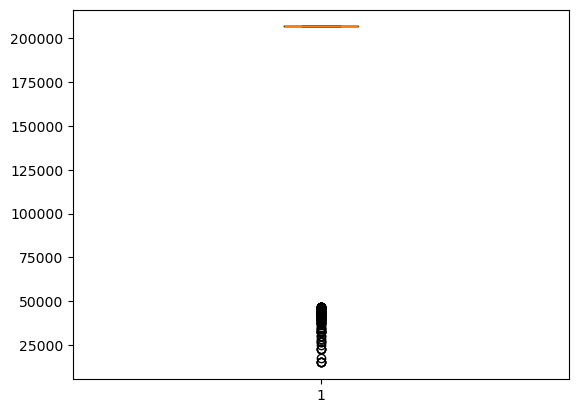

In [29]:
import matplotlib.pyplot as plt

plt.boxplot(df["median_house_value"])

plt.show()

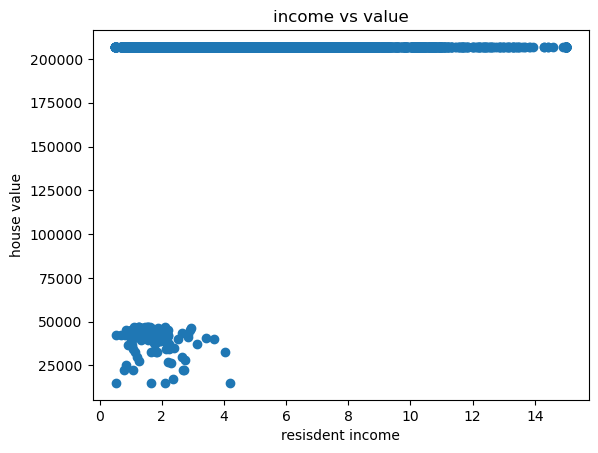

In [30]:
plt.scatter(df["median_income"],df["median_house_value"]) 
plt.title("income vs value") 
plt.xlabel("resisdent income") 
plt.ylabel("house value") 
plt.show() 


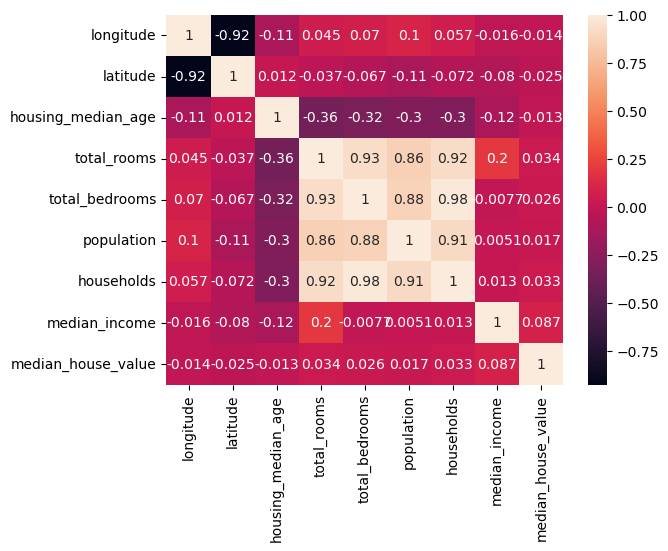

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True),
            annot=True)

plt.show()

In [34]:
#feature selection 
X = df[["median_income",
        "total_rooms",
        "households",
        "total_bedrooms"]]

y = df["median_house_value"]

In [35]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape) 


(16346, 4)
(4087, 4)
(16346,)
(4087,)


In [37]:
from sklearn.linear_model import LinearRegression


In [38]:
model = LinearRegression() 

In [39]:
model.fit(X_train, y_train)

LinearRegression()

In [40]:
y_pred = model.predict(X_test)

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2188.5405079937887
MSE: 133758302.31009562
RMSE: 11565.392440816508
R2 Score: 0.008144834180655147


In [42]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
14416,206864.413155,205268.970916
16383,206864.413155,205825.219263
7731,206864.413155,205970.146698
1410,206864.413155,204691.944586
1335,206864.413155,205958.470855
16260,206864.413155,204343.176808
18011,206864.413155,206771.903840
10086,206864.413155,206299.748745
18294,206864.413155,208014.971049
18733,206864.413155,204357.680932


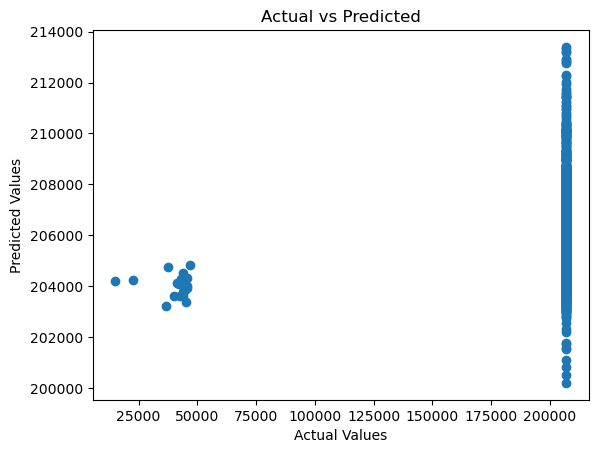

In [43]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

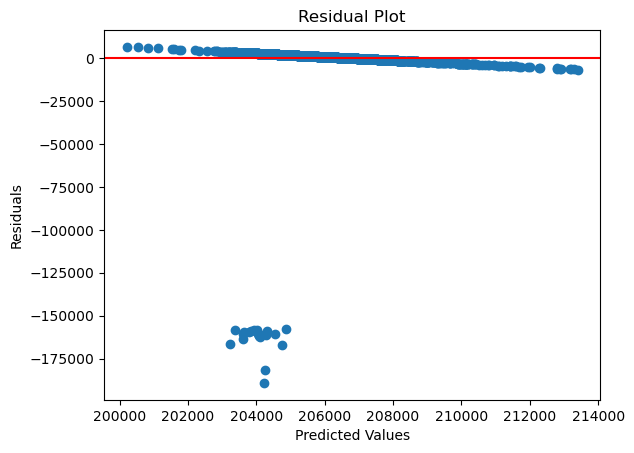

In [44]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [45]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 0.010269831707677146
Test Score: 0.008144834180655147


In [46]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

print("Cross Validation Scores:", scores)
print("Average Score:", scores.mean())

Cross Validation Scores: [0.0073336  0.0052669  0.01114111 0.01128774 0.00931009]
Average Score: 0.008867887893838211


In [49]:
new_data = [[3.0, 25.0, 5.0, 1.0]]  # only 4 features

prediction = model.predict(new_data)
print(prediction)

[204655.53388211]


D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
